### PREPARANDO ENTORNO

In [14]:
!pip install scikit-learn

In [39]:
!pip install umap-learn


   -------------------- ------------------- 1/2 [umap-learn]
   ---------------------------------------- 2/2 [umap-learn]



In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt

### PREPARANDO DATASET

In [30]:
data_df = pd.read_csv("https://media.geeksforgeeks.org/wp-content/uploads/20250516142928101881/data-.csv")

In [31]:
data_df.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,NaN


In [12]:
data_df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

#### Limpiando y Preparando Datos

In [32]:
# Limpiar y preparar datos
data_df = data_df.drop(columns=["Unnamed: 32", "id"], errors="ignore")
data_df["diagnosis"] = data_df["diagnosis"].map({"M": 1, "B": 0})
# Separar features / target
X = data_df.drop(columns=["diagnosis"])
y = data_df["diagnosis"]

### Análisis de PCA, t-SNE y Proyección

#### Preprocesamiento y Division

In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

#### Entrenamiento con SVM + búsqueda de hiperparámetros

In [36]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}
svc = SVC(probability=True)
grid = GridSearchCV(svc, param_grid, cv=5, scoring="roc_auc")
grid.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
best_svc = grid.best_estimator_

Mejores hiperparámetros: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


#### Evaluacion

In [37]:
# 5. Evaluación
y_pred = best_svc.predict(X_test)
y_proba = best_svc.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_proba))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       108
           1       0.98      0.97      0.98        63

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171

AUC-ROC: 0.9977954144620811
Matriz de confusión:
 [[107   1]
 [  2  61]]


### Modelos de Ensamble en el Dataset

#### Preprocesamiento

In [41]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Validacion PCA

In [42]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print("Componentes seleccionadas:", pca.n_components_)
print("Varianza explicada por componentes:", pca.explained_variance_ratio_)

Componentes seleccionadas: 10
Varianza explicada por componentes: [0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734 0.01588724 0.01389649 0.01168978]


#### Visualización con primeros dos componentes

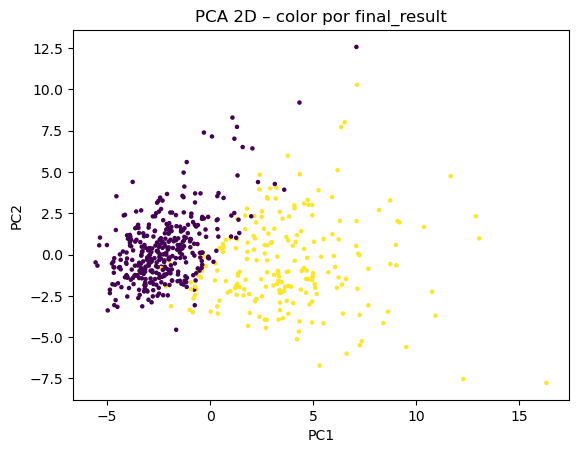

In [47]:
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis", s=5)
plt.title("PCA 2D – color por final_result")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#### Visualización con t-SNE

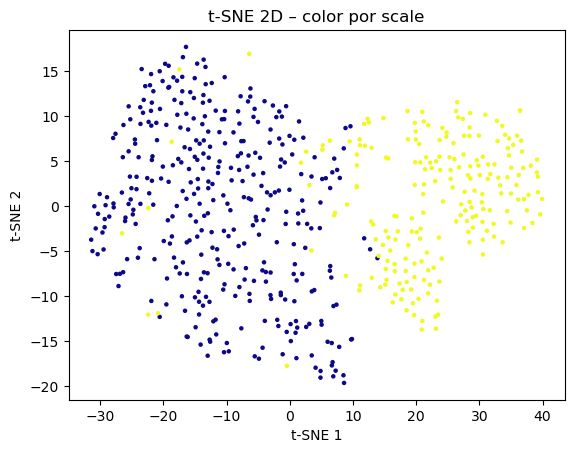

In [48]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="plasma", s=5)
plt.title("t-SNE 2D – color por scale")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

#### Visualización con UMAP

C:\Users\MICHAEL VENTURA\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


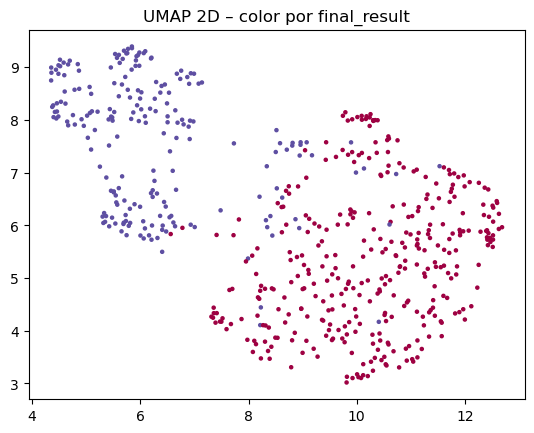

In [49]:
# UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)
plt.figure()
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap="Spectral", s=5)
plt.title("UMAP 2D – color por final_result")
plt.show()